In [ ]:
# NOTE: This notebook details the final data preparation steps for survival analysis.

In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
import json

import matplotlib.pyplot as plt
import seaborn as sns

### Load the survival data
_____

In [2]:
# Load the survival data
with open("data_raw/survival_data.json", "r") as file:
    survival_data = json.load(file)

# Convert survival_data to pandas DataFrame
survival_data_covariates = pd.DataFrame(survival_data)

# Defensive: ensure expected columns exist before casting
for col in ["fu_time2", "fu_time1"]:
    if col in survival_data_covariates.columns:
        survival_data_covariates[col] = pd.to_numeric(survival_data_covariates[col], errors='coerce')

# Combine follow-up periods (if second period missing, use the first)
if {"fu_time1", "fu_time2"}.issubset(survival_data_covariates.columns):
    survival_data_covariates["fu_time"] = survival_data_covariates.apply(
        lambda row: row["fu_time1"] if pd.isna(row["fu_time2"]) else row["fu_time1"] + row["fu_time2"], axis=1
    )
elif "fu_time1" in survival_data_covariates.columns and "fu_time" not in survival_data_covariates.columns:
    survival_data_covariates["fu_time"] = survival_data_covariates["fu_time1"]

# Drop raw period columns if present
survival_data_covariates = survival_data_covariates.drop(columns=[c for c in ["fu_time1", "fu_time2"] if c in survival_data_covariates.columns], errors="ignore")

# NOTE: fu_time assumed in days.

# Rename patients column to Patient_ID if necessary
if "patients" in survival_data_covariates.columns:
    survival_data_covariates = survival_data_covariates.rename(columns={"patients": "Patient_ID"})

# Remove HGSCTB - NaN at the fu_time
survival_data_covariates = survival_data_covariates[survival_data_covariates["fu_time"].notna()]

survival_data_covariates.head(10)

,Patient_ID,age,stage,beva,parpi,io,outcomes_binary,nact,MTIL,TNK,TIP,DAF,samples,sites_binary,CLQ_T_F,CLQ_T_M,BRCA,TMB,event,fu_time
0,HGSC1,<=65,III,No,1,No,Alive,Untreated,-0.0708,332.0,0.0659,-0.4319,SMI_T10_F001,Adnexa,28.0389,29.6029,P,6.80,0.0,1685.0
1,HGSC10,>65,IV,No,1,No,Alive,Untreated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,1.58,0.0,1630.0
2,HGSC102,<=65,III,No,1,No,Alive,Untreated,-0.2230,6.0,0.0262,-0.3665,SMI_T14_F005,Adnexa,59.1704,43.6693,NaN,NaN,0.0,1292.0
3,HGSC104,>65,III,No,1,No,Dead,Untreated,0.0793,34.0,0.3225,-0.4683,SMI_T14_F015,Adnexa,48.2790,32.5718,NaN,NaN,1.0,3054.0
4,HGSC108,>65,III,NaN,NaN,No,Alive,Treated,0.3532,347.0,0.0761,0.3876,SMI_T12_F006,Adnexa,19.0340,14.1021,NaN,NaN,0.0,152.0
5,HGSC109,>65,IV,No,0,No,Alive,Untreated,-0.1220,15.0,-0.1713,0.0049,SMI6K_2_F00022,Adnexa,9.0524,8.1025,NaN,NaN,0.0,2101.0
6,HGSC11,<=65,III,No,1,No,Alive,Untreated,-0.3744,29.0,-0.1634,-0.5581,SMI_T10_F014,Adnexa,87.2712,7.6366,B,6.32,0.0,1978.0
7,HGSC110,<=65,NaN,NaN,NaN,No,Alive,Untreated,-0.1369,316.0,-0.1100,-0.6224,SMI_T12_F009,Adnexa,80.9986,30.0631,NaN,NaN,0.0,13.0
8,HGSC111,>65,IV,No,0,No,Alive,Treated,0.1150,154.0,-0.2674,-0.1871,SMI_T12_F014,Adnexa,6.7951,5.7915,NaN,NaN,0.0,528.0
9,HGSC112,<=65,III,No,1,Yes,Dead,Untreated,0.4166,652.0,0.1168,0.2338,SMI_T12_F015,Adnexa,93.7276,35.7696,NaN,NaN,1.0,2824.0


### Load the cell fractions
____

In [3]:
# Load the cell fractions
with open("data_processed/malignant_proportions_df.pkl", "rb") as file:
    cell_fractions = pkl.load(file)

cell_fractions.head(10)

# Convert C3, C4, EMT, C10, ciliated, Malignant (%), Total Cells columns to numeric types
cell_fractions[["C3", "C4", "EMT", "C10", "ciliated", "Malignant (%)", "Total Cells"]] = cell_fractions[["C3", "C4", "EMT", "C10", "ciliated", "Malignant (%)", "Total Cells"]].apply(pd.to_numeric, errors="coerce")


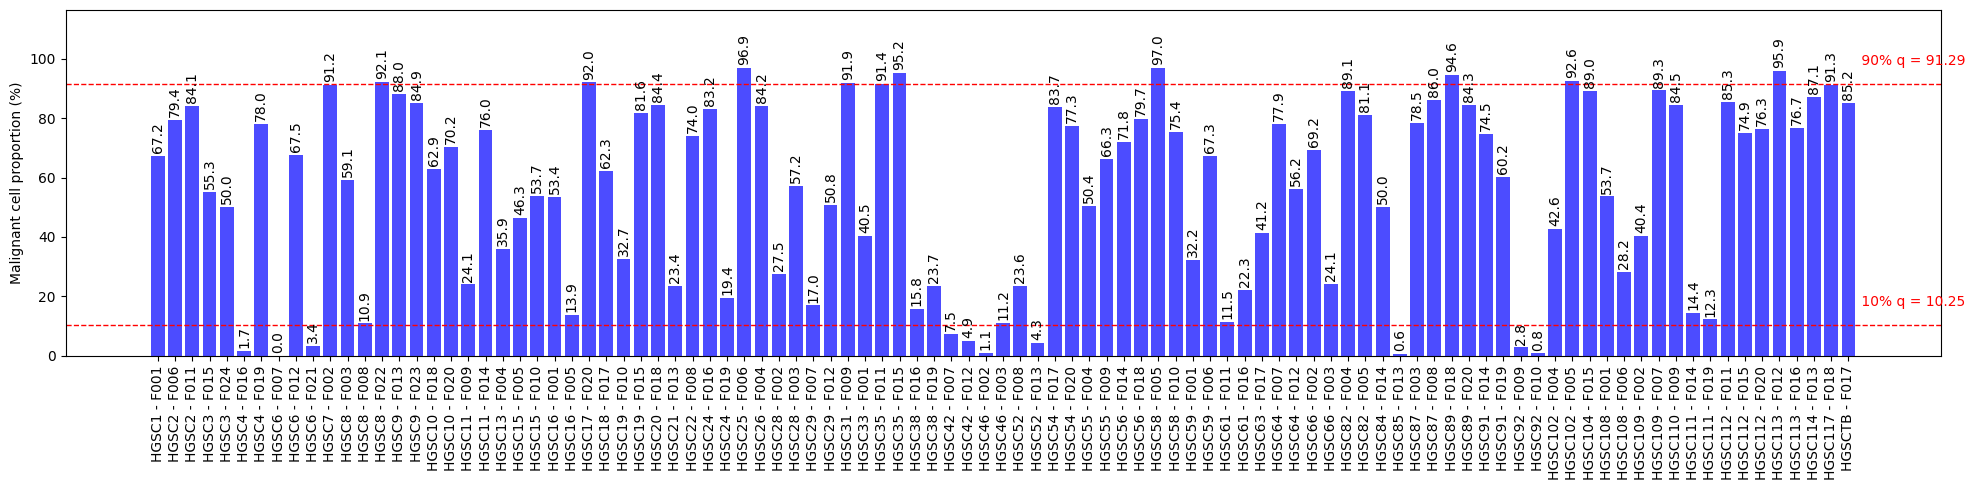

In [4]:
# Plot the distribution of Malignant percentages.
# On the x axis have the Patient + FOV combination
# On the y axis have the Malignant (%)

labels = cell_fractions["Patient_ID"] + " - " + cell_fractions["Frame"]
values = cell_fractions["Malignant (%)"]

fig, ax = plt.subplots(figsize=(20, 5))
bars = ax.bar(labels, values, color="blue", alpha=0.7)

q90 = values.quantile(0.90)
ax.axhline(y=q90, color='r', linestyle='--', linewidth=1)
ax.text(len(labels)-0.5, q90 + 5.5, f" 90% q = {q90:.2f}", color='r', va='bottom', fontsize=10)

q10 = values.quantile(0.10)
ax.axhline(y=q10, color='r', linestyle='--', linewidth=1)
ax.text(len(labels)-0.5, q10 + 5.5, f" 10% q = {q10:.2f}", color='r', va='bottom', fontsize=10)

# Add value labels on top of bars
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2,
            h + max(values)*0.01,          # small offset
            f"{h:.1f}",
            ha="center", va="bottom",
            fontsize=10, rotation=90)

ax.set_ylabel("Malignant cell proportion (%)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=10)
ax.margins(y=0.2)
plt.tight_layout()
plt.show()

# have the patient-fov combinations that are outside the 90% confidence interval
outlier_fractions_proportions = cell_fractions[(cell_fractions["Malignant (%)"] < cell_fractions["Malignant (%)"].quantile(0.10)) | \
                                    (cell_fractions["Malignant (%)"] > cell_fractions["Malignant (%)"].quantile(0.90))]

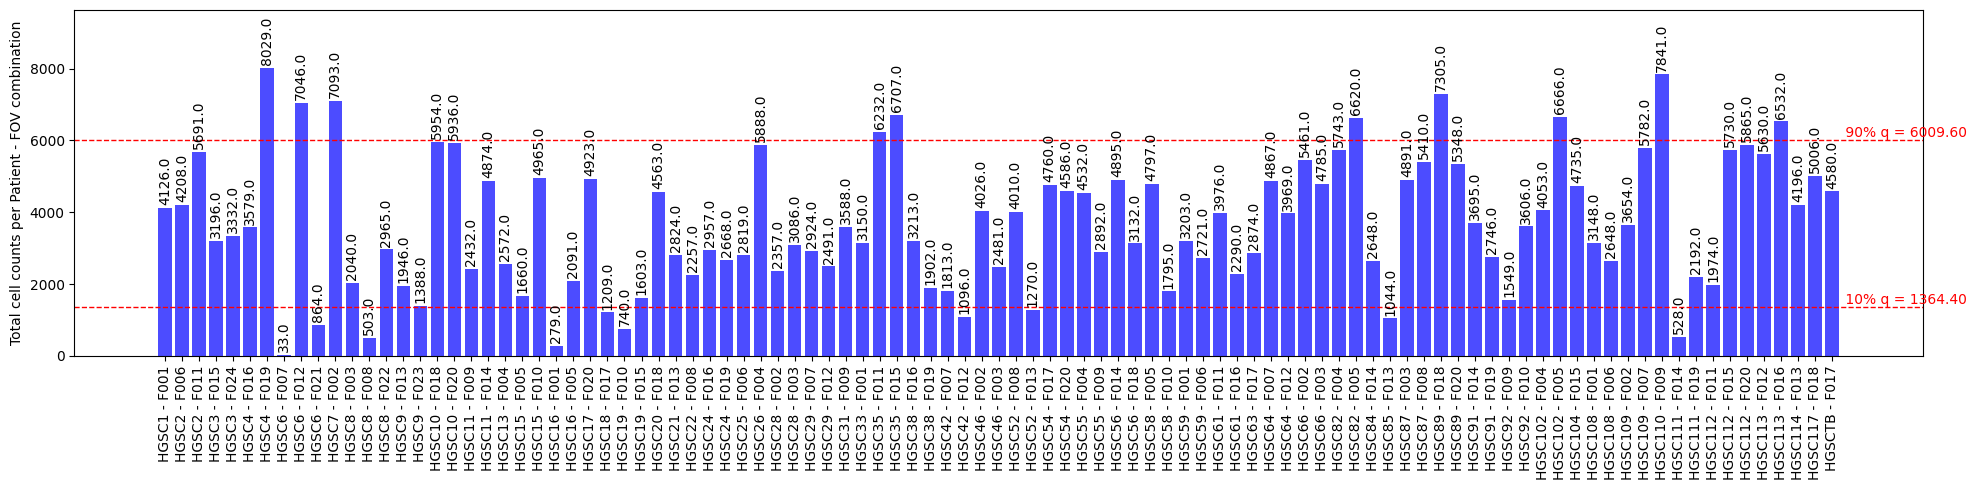

In [5]:
# Also look at the total cell counts per FOV
# this info is stored in cell_fractions["Total Cells"]

cell_fractions["Total Cells"].head(10)

labels = cell_fractions["Patient_ID"] + " - " + cell_fractions["Frame"]
values = cell_fractions["Total Cells"]

fig, ax = plt.subplots(figsize=(20, 5))
bars = ax.bar(labels, values, color="blue", alpha=0.7)

q90 = values.quantile(0.90)
ax.axhline(y=q90, color='r', linestyle='--', linewidth=1)
ax.text(len(labels)-0.5, q90 + 5.5, f" 90% q = {q90:.2f}", color='r', va='bottom', fontsize=10)

q10 = values.quantile(0.10)
ax.axhline(y=q10, color='r', linestyle='--', linewidth=1)
ax.text(len(labels)-0.5, q10 + 5.5, f" 10% q = {q10:.2f}", color='r', va='bottom', fontsize=10)

# Add value labels on top of bars
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2,
            h + max(values)*0.01,          # small offset
            f"{h:.1f}",
            ha="center", va="bottom",
            fontsize=10, rotation=90)

ax.set_ylabel("Total cell counts per Patient - FOV combination")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=10)
# ax.set_ylim(0, 100)
ax.margins(y=0.2)
plt.tight_layout()
plt.show()

# have the patient-fov combinations that are outside the 90% confidence interval
outlier_total_cells = cell_fractions[(cell_fractions["Total Cells"] < cell_fractions["Total Cells"].quantile(0.10)) | \
                                    (cell_fractions["Total Cells"] > cell_fractions["Total Cells"].quantile(0.90))]

Manually validate which patient/fov combination to not keep for further analysis.

In [6]:
# 1. From outlier fraction proportions
# Use lists consistently to avoid membership errors; remove duplicate keys.
raw_do_not_remove = {
    "HGSC25": ["F006"],
    "HGSC8": ["F022"],
    "HGSC17": ["F020"],
    "HGSC31": ["F009"],  # not sure
    "HGSC35": ["F011", "F015"],
    "HGSC58": ["F005"],
    "HGSC89": ["F018"],
    "HGSC102": ["F005"],
    "HGSC113": ["F012"],
}
# Normalize frames to list and uppercase formatting F###
normalize_frame = lambda f: f if f.startswith('F') else f"F{int(f):03d}"

do_not_remove = {p: [normalize_frame(f.upper()) for f in frames] for p, frames in raw_do_not_remove.items()}

mask_drop = outlier_fractions_proportions.apply(
    lambda r: r["Patient_ID"] in do_not_remove and r["Frame"].upper() in do_not_remove[r["Patient_ID"]],
    axis=1
)

outlier_fractions_proportions = outlier_fractions_proportions.loc[~mask_drop].copy()
outlier_fractions_proportions

,Patient_ID,Frame,C3,C4,EMT,C10,ciliated,Malignant (%),Total Cells
5,HGSC4,F016,56.666667,6.666667,5.000000,8.333333,23.333333,1.676446,3579
7,HGSC6,F007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33
9,HGSC6,F021,34.482759,20.689655,10.344828,24.137931,10.344828,3.356481,864
46,HGSC42,F007,20.588235,15.441176,11.029412,2.941176,50.000000,7.501379,1813
47,HGSC42,F012,46.296296,48.148148,0.000000,5.555556,0.000000,4.927007,1096
48,HGSC46,F002,0.000000,35.555556,6.666667,0.000000,57.777778,1.117735,4026
51,HGSC52,F013,29.629630,9.259259,7.407407,16.666667,37.037037,4.251969,1270
72,HGSC85,F013,0.000000,0.000000,100.000000,0.000000,0.000000,0.574713,1044
79,HGSC92,F009,0.000000,0.000000,11.363636,54.545455,34.090909,2.840542,1549
80,HGSC92,F010,0.000000,0.000000,56.666667,0.000000,43.333333,0.831947,3606


In [7]:
# 2. From cell counts
raw_do_not_remove_counts = {
    "HGSC4": ["F019"],  # Not sure
    "HGSC6": ["F012"],
    "HGSC7": ["F002"],
    "HGSC18": ["F017"],
    "HGSC19": ["F010"],
    "HGSC35": ["F011", "F015"],
    "HGSC82": ["F005"],
    "HGSC89": ["F018"],
    "HGSC102": ["F005"],
    "HGSC110": ["F009"],
    "HGSC113": ["F016"],
}
normalize_frame = lambda f: f if f.startswith('F') else f"F{int(f):03d}"

do_not_remove_counts = {p: [normalize_frame(f.upper()) for f in frames] for p, frames in raw_do_not_remove_counts.items()}

mask_drop = outlier_total_cells.apply(
    lambda r: r["Patient_ID"] in do_not_remove_counts and r["Frame"].upper() in do_not_remove_counts[r["Patient_ID"]],
    axis=1
)

outlier_total_cells = outlier_total_cells.loc[~mask_drop].copy()
outlier_total_cells

,Patient_ID,Frame,C3,C4,EMT,C10,ciliated,Malignant (%),Total Cells
7,HGSC6,F007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33
9,HGSC6,F021,34.482759,20.689655,10.344828,24.137931,10.344828,3.356481,864
12,HGSC8,F008,0.000000,0.000000,0.000000,9.090909,90.909091,10.934394,503
23,HGSC16,F001,14.765101,4.026846,42.953020,25.503356,12.751678,53.405018,279
47,HGSC42,F012,46.296296,48.148148,0.000000,5.555556,0.000000,4.927007,1096
51,HGSC52,F013,29.629630,9.259259,7.407407,16.666667,37.037037,4.251969,1270
72,HGSC85,F013,0.000000,0.000000,100.000000,0.000000,0.000000,0.574713,1044
89,HGSC111,F014,11.842105,7.894737,36.842105,13.157895,30.263158,14.393939,528


In [8]:
# Combine outlier Patient/FOV combinations
outlier_fractions_combined = (
    pd.concat([outlier_fractions_proportions, outlier_total_cells], axis=0, ignore_index=True)
      .drop_duplicates(subset=["Patient_ID","Frame"])
)

# Extract numeric parts for proper numeric sorting (HGSC4 < HGSC25 < HGSC102)
outlier_fractions_combined["Patient_num"] = (
    outlier_fractions_combined["Patient_ID"].str.extract(r'(\d+)').astype(int)
)
# Frame like F005 -> 5
outlier_fractions_combined["Frame_num"] = (
    outlier_fractions_combined["Frame"].str.extract(r'(\d+)').astype(int)
)

# Sort by numeric patient, then numeric frame
outlier_fractions_combined = outlier_fractions_combined.sort_values(
    ["Patient_num","Frame_num"]
).drop(columns=["Patient_num","Frame_num"])

outlier_fractions_combined # these are to be removed

,Patient_ID,Frame,C3,C4,EMT,C10,ciliated,Malignant (%),Total Cells
0,HGSC4,F016,56.666667,6.666667,5.000000,8.333333,23.333333,1.676446,3579
1,HGSC6,F007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33
2,HGSC6,F021,34.482759,20.689655,10.344828,24.137931,10.344828,3.356481,864
12,HGSC8,F008,0.000000,0.000000,0.000000,9.090909,90.909091,10.934394,503
13,HGSC16,F001,14.765101,4.026846,42.953020,25.503356,12.751678,53.405018,279
3,HGSC42,F007,20.588235,15.441176,11.029412,2.941176,50.000000,7.501379,1813
4,HGSC42,F012,46.296296,48.148148,0.000000,5.555556,0.000000,4.927007,1096
5,HGSC46,F002,0.000000,35.555556,6.666667,0.000000,57.777778,1.117735,4026
6,HGSC52,F013,29.629630,9.259259,7.407407,16.666667,37.037037,4.251969,1270
7,HGSC85,F013,0.000000,0.000000,100.000000,0.000000,0.000000,0.574713,1044


In [9]:
print(len(outlier_fractions_combined["Patient_ID"].unique()))
print(len(outlier_fractions_proportions["Patient_ID"].unique()))
print(len(outlier_total_cells["Patient_ID"].unique()))

10
7
7


In [10]:
# Remove the above patient - FOV combinations from the spatial metrics.
# Build a set of (Patient_ID, Frame) pairs for faster exact matching
remove_pairs = set(zip(outlier_fractions_combined['Patient_ID'].astype(str),
                       outlier_fractions_combined['Frame'].astype(str)))

cell_fractions = cell_fractions.loc[
    ~cell_fractions.apply(
        lambda r: (str(r['Patient_ID']), str(r['Frame'])) in remove_pairs,
        axis=1
    )
].copy()

cell_fractions

,Patient_ID,Frame,C3,C4,EMT,C10,ciliated,Malignant (%),Total Cells
0,HGSC1,F001,2.379236,10.850757,7.390050,45.205479,34.174477,67.232186,4126
1,HGSC2,F006,38.293413,10.598802,7.934132,40.718563,2.455090,79.372624,4208
2,HGSC2,F011,61.470957,2.402842,0.000000,36.021730,0.104471,84.097698,5691
3,HGSC3,F015,35.673839,9.966025,26.896942,7.361268,20.101925,55.256571,3196
4,HGSC3,F024,19.447779,3.781513,51.380552,11.764706,13.625450,50.000000,3332
...,...,...,...,...,...,...,...,...,...
94,HGSC113,F012,0.814966,7.612521,19.688831,54.102612,17.781071,95.896980,5630
95,HGSC113,F016,0.379242,8.742515,41.996008,40.738523,8.143713,76.699326,6532
96,HGSC114,F013,9.006296,0.191623,64.193813,16.972351,9.635916,87.059104,4196
97,HGSC117,F018,27.992996,27.205078,27.402057,14.664040,2.735828,91.270475,5006


### Load the spatial metrics
________

In [11]:
# Load the spatial metrics
spatial_metrics = pd.read_csv("data_processed/spatial_metrics.csv")


# Change "patient" column title to "Patient_ID"
spatial_metrics = spatial_metrics.rename(columns={"patient": "Patient_ID"})
# Change "FOV" column title to "Frame"
spatial_metrics = spatial_metrics.rename(columns={"FOV": "Frame"})

spatial_metrics.head()

,Patient_ID,Frame,ripley_B.cell_auc_clustering,ripley_Endothelial_auc_clustering,ripley_Fibroblast_auc_clustering,ripley_Malignant.C10_auc_clustering,ripley_Malignant.C3_auc_clustering,ripley_Malignant.C4_auc_clustering,ripley_Malignant.EMT_auc_clustering,ripley_Malignant.Other_auc_clustering,...,300um_CLQ_Malignant.EMT_B.cell,300um_CLQ_Malignant.EMT_Endothelial,300um_CLQ_Malignant.EMT_Fibroblast,300um_CLQ_Malignant.EMT_Malignant.C10,300um_CLQ_Malignant.EMT_Malignant.C3,300um_CLQ_Malignant.EMT_Malignant.C4,300um_CLQ_Malignant.EMT_Malignant.ciliated,300um_CLQ_Malignant.EMT_Mast.cell,300um_CLQ_Malignant.EMT_Monocyte,300um_CLQ_Malignant.EMT_TNK.cell
0,HGSC1,F001,66213.459789,89539.363282,5.597913e+05,1.067450e+06,61806.424385,240069.399087,1.623359e+05,430807.798000,...,1063.367415,1229.428082,1030.740665,1507.974104,1520.845676,1583.502196,1421.905943,NaN,1485.237215,1389.998485
1,HGSC10,F018,5059.460310,61966.471319,5.626921e+05,5.732536e+05,185362.151804,830181.694594,2.135655e+05,316110.142851,...,NaN,2091.831206,2057.919408,3214.746520,2043.483451,2477.647667,2519.280462,NaN,2114.023708,1615.428454
2,HGSC10,F020,20560.759140,33359.102662,5.433683e+05,1.269598e+06,66611.545691,496697.590995,8.197738e+04,330858.261977,...,1162.061517,2509.713546,2485.370521,2550.376048,2563.852155,2507.802306,2316.045906,NaN,2640.263780,2648.135338
3,HGSC102,F004,NaN,106083.251463,1.320168e+06,9.150710e+04,13087.317243,164532.178357,9.498546e+05,241573.939257,...,NaN,1510.632524,1654.144239,1657.089934,NaN,1944.816295,1986.400816,NaN,1609.327148,1400.660038
4,HGSC102,F005,NaN,68659.890679,1.215900e+05,6.408253e+05,12544.964102,11645.319705,2.356231e+06,418897.822243,...,NaN,2735.490706,2424.447597,3157.415911,NaN,NaN,2826.517929,NaN,2703.595474,NaN


### Merge the dataframes
____

In [12]:
# merge the spatial_metrics DataFrame with cell_fractions Data_frames on Patient_ID and Frame Combinations
for df_ in (spatial_metrics, cell_fractions):
    # Ensure string
    df_["Patient_ID"] = df_["Patient_ID"].astype(str)
    df_["Frame"] = df_["Frame"].astype(str)
    # Optional: normalize Frame to pattern F### (only if needed)
    df_["Frame"] = df_["Frame"].str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)
    df_["Frame"] = df_["Frame"].str.replace(r'^F?(\d+)$', lambda m: f"F{int(m.group(1)):03d}", regex=True)

# Drop exact duplicate (Patient_ID, Frame) rows if any
spatial_metrics = spatial_metrics.drop_duplicates(subset=["Patient_ID","Frame"])
cell_fractions = cell_fractions.drop_duplicates(subset=["Patient_ID","Frame"])

# Merge (inner keeps only pairs present in both)
merged_df = spatial_metrics.merge(
    cell_fractions,
    on=["Patient_ID", "Frame"],
    how="inner",
    suffixes=("_metrics", "_fractions")
)

# Optional: report unmatched
missing_in_fractions = set(spatial_metrics.set_index(["Patient_ID","Frame"]).index) - set(merged_df.set_index(["Patient_ID","Frame"]).index)
missing_in_metrics = set(cell_fractions.set_index(["Patient_ID","Frame"]).index) - set(merged_df.set_index(["Patient_ID","Frame"]).index)

print(f"Rows in spatial_metrics not merged: {len(missing_in_fractions)}")
print(f"Rows in cell_fractions not merged: {len(missing_in_metrics)}")

merged_df.head(10)

Rows in spatial_metrics not merged: 13
Rows in cell_fractions not merged: 0


,Patient_ID,Frame,ripley_B.cell_auc_clustering,ripley_Endothelial_auc_clustering,ripley_Fibroblast_auc_clustering,ripley_Malignant.C10_auc_clustering,ripley_Malignant.C3_auc_clustering,ripley_Malignant.C4_auc_clustering,ripley_Malignant.EMT_auc_clustering,ripley_Malignant.Other_auc_clustering,...,300um_CLQ_Malignant.EMT_Mast.cell,300um_CLQ_Malignant.EMT_Monocyte,300um_CLQ_Malignant.EMT_TNK.cell,C3,C4,EMT,C10,ciliated,Malignant (%),Total Cells
0,HGSC1,F001,66213.459789,89539.363282,5.597913e+05,1.067450e+06,61806.424385,2.400694e+05,1.623359e+05,430807.798000,...,NaN,1485.237215,1389.998485,2.379236,10.850757,7.390050,45.205479,34.174477,67.232186,4126
1,HGSC10,F018,5059.460310,61966.471319,5.626921e+05,5.732536e+05,185362.151804,8.301817e+05,2.135655e+05,316110.142851,...,NaN,2114.023708,1615.428454,7.774512,36.708523,8.121827,24.926530,22.468608,62.865301,5954
2,HGSC10,F020,20560.759140,33359.102662,5.433683e+05,1.269598e+06,66611.545691,4.966976e+05,8.197738e+04,330858.261977,...,NaN,2640.263780,2648.135338,2.424970,20.624250,3.193277,53.733493,20.024010,70.165094,5936
3,HGSC102,F004,NaN,106083.251463,1.320168e+06,9.150710e+04,13087.317243,1.645322e+05,9.498546e+05,241573.939257,...,NaN,1609.327148,1400.660038,0.521135,8.859294,59.640996,5.500869,25.477707,42.610412,4053
4,HGSC102,F005,NaN,68659.890679,1.215900e+05,6.408253e+05,12544.964102,1.164532e+04,2.356231e+06,418897.822243,...,NaN,2703.595474,NaN,0.226794,0.210595,77.612182,20.152276,1.798153,92.604260,6666
5,HGSC104,F015,0.000000,35998.806102,2.788378e+05,1.505094e+06,953989.729184,8.588112e+04,3.023701e+05,424847.830132,...,NaN,1918.699359,2392.191729,28.951115,2.373042,10.370195,50.593261,7.712387,88.996832,4735
6,HGSC108,F001,839564.719225,144888.607752,9.382890e+04,6.635089e+05,305789.128559,7.657853e+05,1.583876e+04,392081.907790,...,NaN,NaN,NaN,15.926584,45.411486,0.651273,36.648905,1.361753,53.653113,3148
7,HGSC108,F006,106052.333614,110979.072151,6.566813e+05,6.265318e+03,NaN,1.221632e+06,NaN,158203.901137,...,NaN,NaN,NaN,0.000000,99.598930,0.000000,0.401070,0.000000,28.247734,2648
8,HGSC109,F002,124153.296967,154097.315727,1.508255e+06,2.618388e+05,431710.029787,9.936853e+04,3.889820e+04,188287.440399,...,NaN,1019.810811,836.805970,27.710027,5.216802,2.032520,16.056911,48.983740,40.394089,3654
9,HGSC109,F007,NaN,72941.377764,2.333187e+05,1.092085e+04,NaN,9.486164e+05,5.589075e+04,414763.362470,...,NaN,1719.832267,NaN,0.000000,25.261527,1.549787,0.329330,72.859357,89.277067,5782


In [13]:
# === Simple patient-level averaging (skip NaNs) ===
# NOTE: Any NaNs in a column for some FOVs are ignored in the mean.
# If a patient has only one FOV and that value is NaN, the patient-level value remains NaN (desired).

# Identify numeric columns (exclude key columns)
key_cols = {"Patient_ID", "Frame"}
numeric_cols = [
    c for c in merged_df.columns
    if merged_df[c].dtype.kind in "iuf" and c not in key_cols
]

# Simple mean per patient (skipna=True by default)
patient_level_metrics = (
    merged_df.groupby("Patient_ID")[numeric_cols]
    .mean()            # NaNs automatically ignored
    .reset_index()
)

# Merge with survival covariates (inner: only patients with metrics)
survival_analysis_df = survival_data_covariates.merge(
    patient_level_metrics, on="Patient_ID", how="inner"
)

print(f"Patients in survival data: {survival_data_covariates.Patient_ID.nunique()}")
print(f"Patients with metrics: {patient_level_metrics.Patient_ID.nunique()}")
print(f"Final rows (patients) for survival analysis: {survival_analysis_df.Patient_ID.nunique()}")

survival_analysis_df.head(20)

Patients in survival data: 95
Patients with metrics: 55
Final rows (patients) for survival analysis: 54


,Patient_ID,age,stage,beva,parpi,io,outcomes_binary,nact,MTIL,TNK,...,300um_CLQ_Malignant.EMT_Mast.cell,300um_CLQ_Malignant.EMT_Monocyte,300um_CLQ_Malignant.EMT_TNK.cell,C3,C4,EMT,C10,ciliated,Malignant (%),Total Cells
0,HGSC1,<=65,III,No,1,No,Alive,Untreated,-0.0708,332.0,...,NaN,1485.237215,1389.998485,2.379236,10.850757,7.390050,45.205479,34.174477,67.232186,4126.0
1,HGSC10,>65,IV,No,1,No,Alive,Untreated,NaN,NaN,...,NaN,2377.143744,2131.781896,5.099741,28.666386,5.657552,39.330011,21.246309,66.515197,5945.0
2,HGSC102,<=65,III,No,1,No,Alive,Untreated,-0.2230,6.0,...,NaN,2156.461311,1400.660038,0.373965,4.534944,68.626589,12.826572,13.637930,67.607336,5359.5
3,HGSC104,>65,III,No,1,No,Dead,Untreated,0.0793,34.0,...,NaN,1918.699359,2392.191729,28.951115,2.373042,10.370195,50.593261,7.712387,88.996832,4735.0
4,HGSC108,>65,III,NaN,NaN,No,Alive,Treated,0.3532,347.0,...,NaN,NaN,NaN,7.963292,72.505208,0.325636,18.524987,0.680876,40.950424,2898.0
5,HGSC109,>65,IV,No,0,No,Alive,Untreated,-0.1220,15.0,...,NaN,1369.821539,836.805970,13.855014,15.239164,1.791154,8.193120,60.921548,64.835578,4718.0
6,HGSC11,<=65,III,No,1,No,Alive,Untreated,-0.3744,29.0,...,NaN,1354.198802,1066.958615,2.714016,5.889357,69.135305,7.339418,14.921904,50.014418,3653.0
7,HGSC110,<=65,NaN,NaN,NaN,No,Alive,Untreated,-0.1369,316.0,...,NaN,3371.904669,3461.161403,0.000000,0.000000,85.988223,0.347275,13.664502,84.466267,7841.0
8,HGSC111,>65,IV,No,0,No,Alive,Treated,0.1150,154.0,...,NaN,976.753679,980.815471,0.000000,1.115242,31.598513,1.858736,65.427509,12.271898,2192.0
9,HGSC112,<=65,III,No,1,Yes,Dead,Untreated,0.4166,652.0,...,1872.017805,1908.445110,1879.197437,3.104469,61.782665,24.442352,6.706058,3.964456,78.843255,4523.0


In [ ]:
# Save the survival dataframe to csv
# survival_analysis_df.to_csv("data_processed/survival_data_full.csv")